# ICWSM Paper Source Code



In [13]:

from matplotlib.lines import Line2D
from textwrap import fill
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import json

from scipy.stats import mannwhitneyu
import json


## Figure: Gender Distribution of Candidates by Political Party (Figure 1)

Figure provides a descriptive overview of the gender distribution of all official candidates in the 2025 Canadian federal election, broken down by political party. This analysis includes the complete slate of 1,562 official candidates, not just the 921 who were active on social media, providing a baseline for gender representation at the party level.

In [14]:
df = pd.read_json("./data/canada_2025_candidates.jsonl", lines=True)
print("Official Candidates Dataset Size:", len(df))
GENDER_PALETTE = {"Female": "#FF7F0E", "Male": "#6E6E6E"}

Official Candidates Dataset Size: 1562


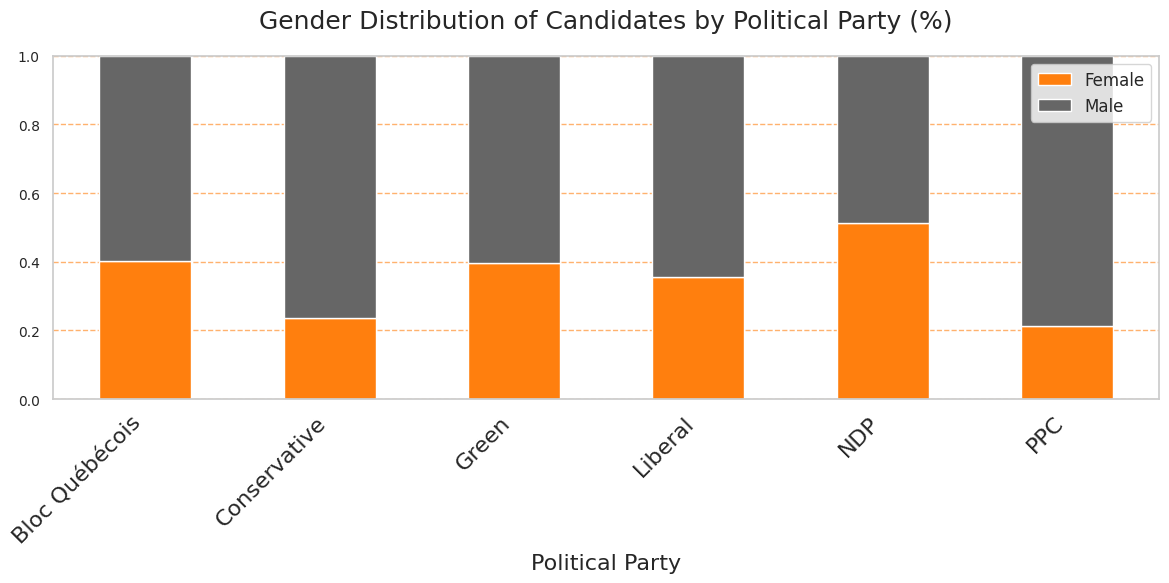

In [15]:
import matplotlib.pyplot as plt

df['gender'] = df['gender'].str.strip().str.title()

gender_by_party = df.groupby(['Party', 'gender']).size().unstack(fill_value=0)
gender_by_party_pct = gender_by_party.div(gender_by_party.sum(axis=1), axis=0)  # normalize

colors = {'Female': '#FF7F0E', 'Male': '#666666'}

fig, ax = plt.subplots(figsize=(12, 6))

gender_by_party_pct[['Female','Male']].plot(
    kind='bar',
    stacked=True,
    color=[colors['Female'], colors['Male']],
    ax=ax
)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plt.title("Gender Distribution of Candidates by Political Party (%)", fontsize=18, pad=20)
plt.xlabel("Political Party", fontsize=16)
plt.ylabel("", fontsize=14)

# Legend
plt.legend(title="", title_fontsize=14, fontsize=12, loc="upper right")

plt.xticks(rotation=45, ha="right", fontsize=16)
plt.yticks(fontsize=10)
plt.ylim(0, 1)

plt.grid(axis='y', linestyle='--', alpha=0.6, color="#FF7F0E")

plt.tight_layout()
plt.show()


## Figure: Gender Bias Score (GBS) by Platform and Party (Figure 2)
Figure 2 visualizes the Gender Bias Score (GBS), a metric we defined to quantify the relative posting intensity between male and female candidates while controlling for the number of candidates in each group. The score is computed by subtracting the average number of posts per female candidate from the average number of posts per male candidate. A positive score indicates that, on average, male candidates post more frequently, while a negative score indicates greater posting intensity for female candidates.

In [16]:
df = pd.read_json("./data/canadian_election_2025_posts.jsonl", lines=True)
print("Candidate Posts Dataset Size:", len(df))

Candidate Posts Dataset Size: 193620


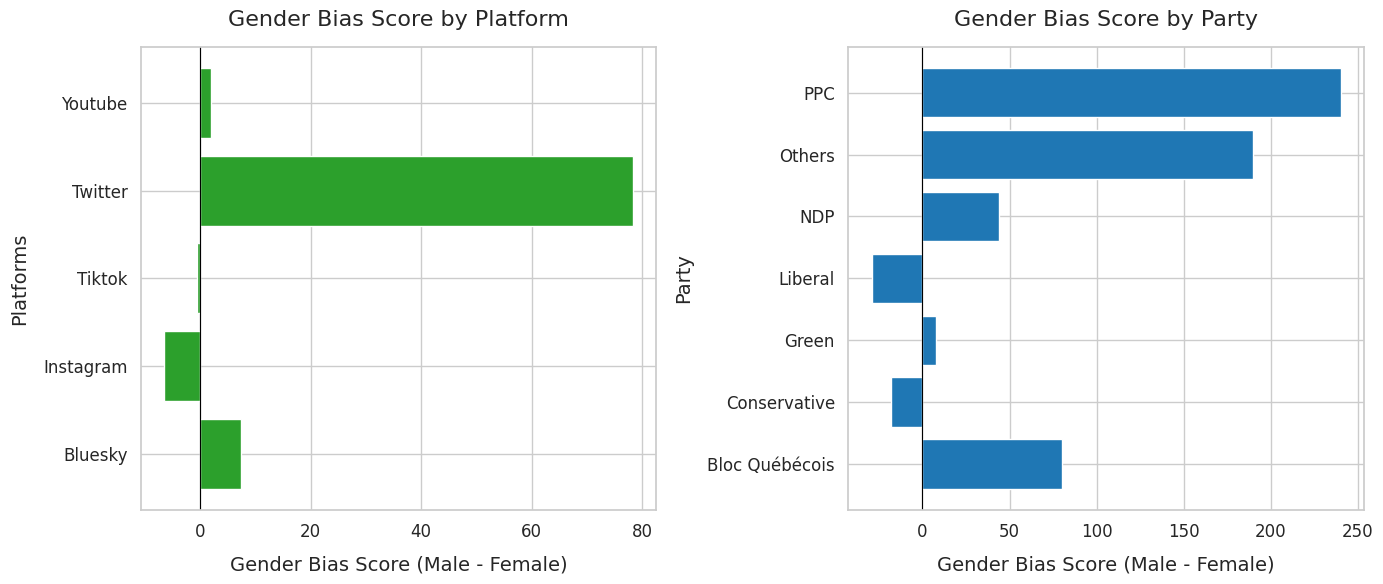

In [17]:

df['party'] = df['party'].fillna('Others')
df['party'] = df['party'].replace('', 'Others')
def compute_gbs(df, group_col):
    results = []
    for name, group in df.groupby(group_col):
        male_posts = group[group['gender'].str.lower() == 'male']['id'].nunique()
        male_users = group[group['gender'].str.lower() == 'male']['candidate_id'].nunique()
        female_posts = group[group['gender'].str.lower() == 'female']['id'].nunique()
        female_users = group[group['gender'].str.lower() == 'female']['candidate_id'].nunique()

        male_rate = male_posts / male_users if male_users > 0 else 0
        female_rate = female_posts / female_users if female_users > 0 else 0
        gbs = male_rate - female_rate
        results.append({group_col: name, 'GBS': gbs})
    return pd.DataFrame(results)


gbs_platform = compute_gbs(df, 'platform')
gbs_party = compute_gbs(df, 'party')

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# Platform plot
axes[0].barh(gbs_platform['platform'], gbs_platform['GBS'], color='#2ca02c')
axes[0].set_title("Gender Bias Score by Platform", fontsize=16, pad=15)
axes[0].set_xlabel("Gender Bias Score (Male - Female)", fontsize=14, labelpad=10)
axes[0].set_ylabel("Platforms", fontsize=14, labelpad=10)
axes[0].tick_params(axis='both', which='major', labelsize=12)  # tick font büyüt
axes[0].axvline(0, color="black", linewidth=0.8)

# Party plot
axes[1].barh(gbs_party['party'], gbs_party['GBS'], color='#1f77b4')
axes[1].set_title("Gender Bias Score by Party", fontsize=16, pad=15)
axes[1].set_xlabel("Gender Bias Score (Male - Female)", fontsize=14, labelpad=10)
axes[1].set_ylabel("Party", fontsize=14, labelpad=10)
axes[1].tick_params(axis='both', which='major', labelsize=12)
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()



## Figure: Distribution of likes (Figure 3)

Figure 3 shows the distribution of likes for original, candidategenerated content by gender and party, plotted on a logarithmic scale. Each box shows the interquartile range (IQR),
with the central line indicating the median.

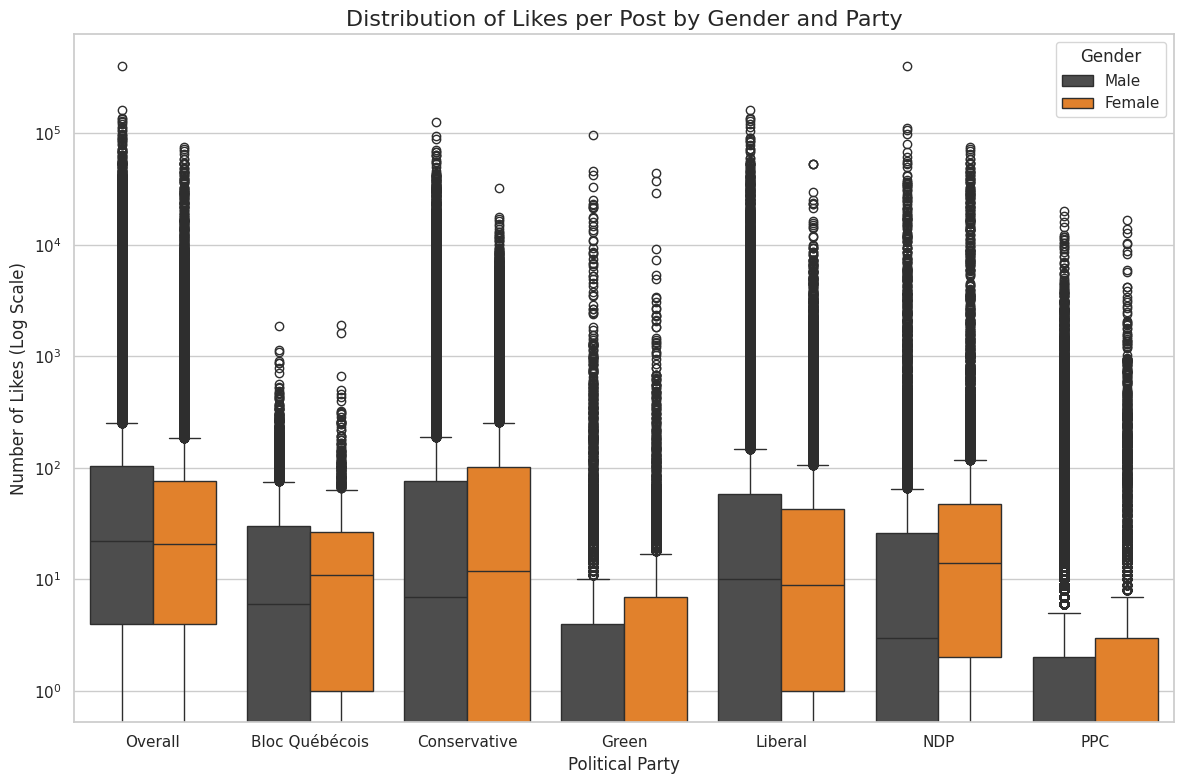

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_json("./data/canadian_election_2025_posts.jsonl", lines=True)

if df is not None:

    df['like_count'] = pd.to_numeric(df['like_count'], errors='coerce')
    df['gender'] = df['gender'].str.strip().str.title()

    parties_to_plot = ['Conservative', 'Liberal', 'Green', 'NDP', 'PPC',
       'Bloc Québécois']
    plot_df = df[df['party'].isin(parties_to_plot)].copy()

    overall_df = df[df["original"]].copy()
    overall_df['party'] = 'Overall'
    plot_df = pd.concat([overall_df, plot_df])


    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid")


    ax = sns.boxplot(
        data=plot_df,
        x='party',
        y='like_count',
        hue='gender',
        palette={'Female': '#FF7F0E', 'Male': '#4D4D4D'},
        order=['Overall',  'Bloc Québécois','Conservative', 'Green', 'Liberal', 'NDP', 'PPC',
      ]
    )


    ax.set_yscale('log')


    ax.set_title('Distribution of Likes per Post by Gender and Party', fontsize=16)
    ax.set_xlabel('Political Party', fontsize=12)
    ax.set_ylabel('Number of Likes (Log Scale)', fontsize=12)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    plt.legend(title='Gender')

    plt.tight_layout()
    plt.show()

## Figure Timelines (Figure 4)

Normalized daily posting activity by gender for
each major political party, smoothed with a 7-day rolling
average. The y-axis shows the average number of posts per
candidate. The vertical dashed lines indicate the start (March
23) and end (April 28) of the official campaign period.

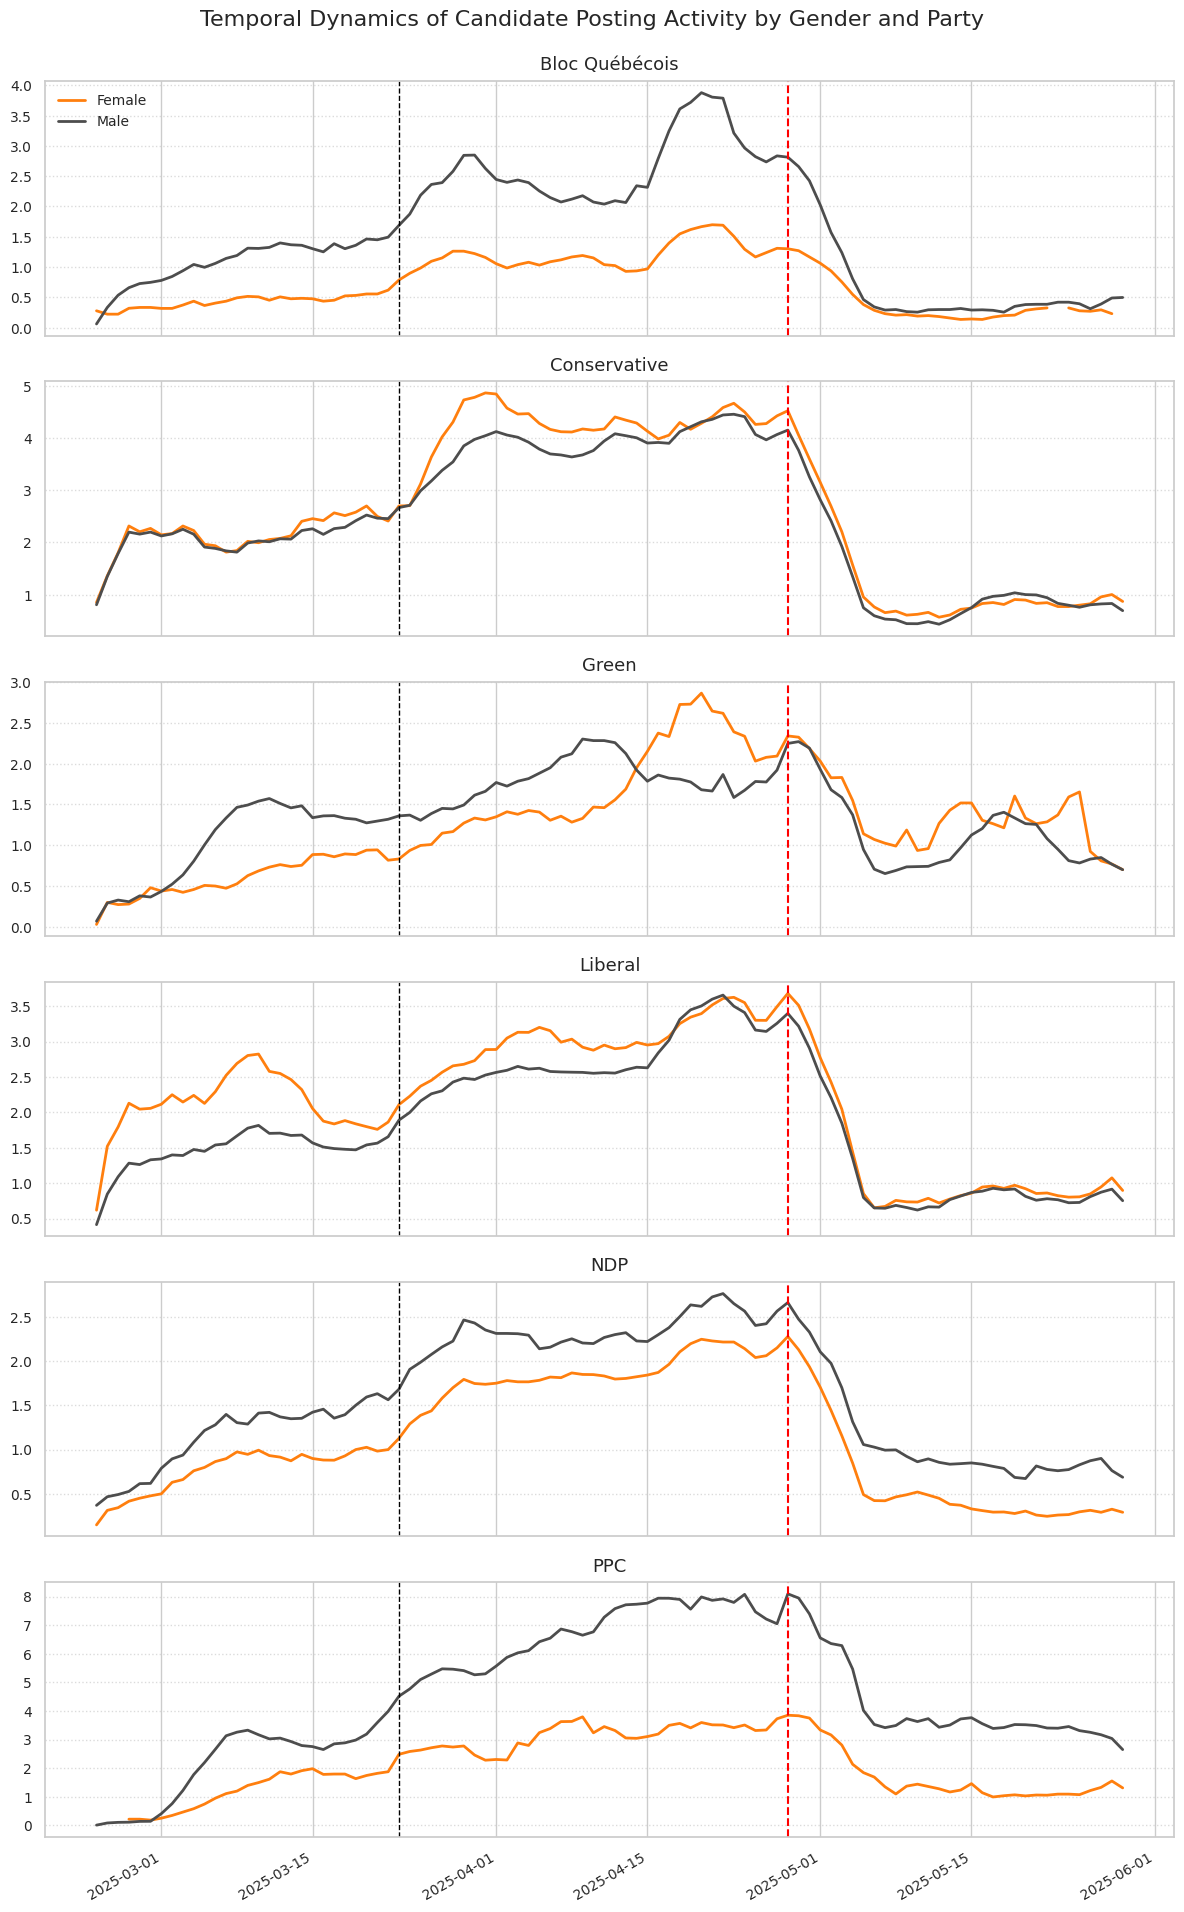

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- CONFIG ----
COLORS = {'Female': '#FF7F0E', 'Male': '#4D4D4D'}  # orange / dark gray
CALL_DATE = pd.Timestamp('2025-03-23')
ELECTION_DAY = pd.Timestamp('2025-04-28')

def prep_df(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['date'] = df['date'].dt.floor('D')
    df['gender'] = df['gender'].str.strip().str.title()
    df['party'] = df['party'].fillna('Others').replace(['', '(empty)'], 'Others')
    return df

def daily_avg_posts(df, group_col, mode='total', smooth=7):

    daily_posts = (
        df.groupby(['date', group_col, 'gender'])
          .size().rename('post_count')
          .reset_index()
    )

    if mode == 'daily':
        denom = (df.groupby(['date', group_col, 'gender'])['candidate_id']
                   .nunique().rename('denom').reset_index())
        out = daily_posts.merge(denom, on=['date', group_col, 'gender'], how='left')

    elif mode == 'total':
        denom = (df.groupby([group_col, 'gender'])['candidate_id']
                   .nunique().rename('denom').reset_index())
        out = daily_posts.merge(denom, on=[group_col, 'gender'], how='left')

    else:
        raise ValueError("mode must be 'daily' or 'total'")

    out['avg_per_candidate'] = out['post_count'] / out['denom'].replace(0, pd.NA)

    # smoothing per group x gender
    out = (out.set_index('date')
              .groupby([group_col, 'gender'])['avg_per_candidate']
              .apply(lambda s: s.sort_index().rolling(smooth, min_periods=1).mean())
              .reset_index()
              .rename(columns={'avg_per_candidate':'avg_smooth'}))
    return out

def plot_timelines(tidy, group_col, title_prefix):

    tidy = tidy[tidy[group_col].ne('Others')]

    groups = sorted(tidy[group_col].dropna().unique())
    fig, axes = plt.subplots(len(groups), 1, figsize=(12, 3.2*len(groups)), sharex=True)
    if len(groups) == 1: axes = [axes]

    for ax, g in zip(axes, groups):
        sub = (tidy[tidy[group_col]==g]
               .pivot(index='date', columns='gender', values='avg_smooth')
               .sort_index())
        for sex in ['Female','Male']:
            if sex in sub.columns:
                ax.plot(sub.index, sub[sex], label=sex, color=COLORS[sex], linewidth=2.0)

        ax.set_title(str(g), fontsize=13, pad=8)
        ax.grid(axis='y', linestyle=':', linewidth=1, alpha=0.7)
        ax.tick_params(axis='both', labelsize=10)

        ax.axvline(CALL_DATE,   color='black', linestyle='--', linewidth=1)
        ax.axvline(ELECTION_DAY, color='red',   linestyle='--', linewidth=1.5)

    axes[0].legend(frameon=False, fontsize=10, loc='upper left')
    fig.suptitle(f'{title_prefix}', fontsize=16, y=0.995)
    fig.autofmt_xdate(); plt.tight_layout(); plt.show()



df2 = prep_df(df)
party_B = daily_avg_posts(df2, group_col='party', mode='total', smooth=7)
plot_timelines(party_B, 'party', 'Temporal Dynamics of Candidate Posting Activity by Gender and Party')


## Figure : Gender and Topics (Figure 5)
Gendered share of discourse for each topic, sorted
in descending order of female engagement. To control for
the numerical imbalance between candidates, the share
is calculated from normalized per-candidate posting rates
rather than raw post counts. The dashed vertical line indicates the average female share of discourse (44.0%) across
all topics.


In [20]:
top_topics = (
    df[df['topic_id'] > -1]['topic_id']
    .value_counts()
    .head(50)
    .index
    .tolist()
)
top_topics_set = set(top_topics)
#removing noise ones
top_topics_set.remove(0)
top_topics_set.remove(1)
#Those labels are generated based on top 10 words of each topic This is top 50
custom_labels = {
  0:  "Casual Agreement & Reactions",
  1:  "Noise / Empty Tokens",
  2:  "Volunteering & Campaign Teams",
  3:  "Housing Affordability & Crisis",
  4:  "Israel–Palestine Conflict",
  5:  "Budget, Debt & Food Prices",
  6:  "Oil, Energy & Climate",
  7:  "Tariffs & Trade Disputes",
  8:  "Volunteer Momentum & Campaigning",
  9:  "Ukraine–Russia War",
  10: "Voting Locations & Advance Polls",
  11: "Political Parties & Ideologies",
  12: "Economic Nationalism & Boycotts",
  13: "Elections & Voting Logistics",
  14: "Crime & Public Safety",
  15: "Dining & Local Food Culture",
  16: "Carbon Tax & Industrial Policy",
  17: "Seniors & Retirement Programs",
  18: "Labour Unions & Worker Rights",
  19: "Vaccination & Public Health",
  20: "Gender Equality & Women's Day",
  21: "Lawn Sign Requests",
  22: "Satire, Glitches & Technical Errors",
  23: "China–Canada Relations & Interference",
  24: "Healthcare & Pharmacare",
  25: "Capital Gains & Income Tax Cuts",
  26: "PPC Campaigns & 2025 Election Tags",
  27: "Filipino Festival & Community Mourning",
  28: "Gratitude & Public Appreciation",
  29: "Political Scandals & Mistrust",
  30: "Plagiarism & Academic Integrity",
  31: "Pope Francis & Catholic Community",
  32: "Electoral Reform & Party Platforms",
  33: "Cultural & Religious Celebrations",
  34: "Vote Splitting & Party Support",
  35: "Easter & Christian Faith",
  36: "Trump & Foreign Policy Ideology",
  37: "Media Trust & Defunding Debates",
  38: "Reconciliation, Transit & Fisheries",
  39: "Hockey Playoffs & Fan Excitement",
  40: "Québec Identity & Language Politics",
  41: "Fentanyl & Addiction Crisis",
  42: "Local Politics in West Island",
  43: "New Cabinet & Minister Appointments",
  44: "Alberta Sovereignty & Referendum",
  45: "Media Bias & Journalism Criticism",
  46: "Supply Management & Dairy Farmers",
  47: "Parliament & Oath of Office",
  48: "Dental Care Program & Eligibility",
  49: "Nature Conservation & Biodiversity"
}


In [21]:
df = df[df["topic_id"].isin(top_topics_set)]

all_labels = [
    custom_labels.get(int(topic), f"Unlabelled") if topic in top_topics_set else "Unlabelled"
    if topic != -1 else "Outlier"
    for topic in df['topic_id']
]

Topics after 500-post filter: 48
Avg female share (per-candidate normalized): 44.1%


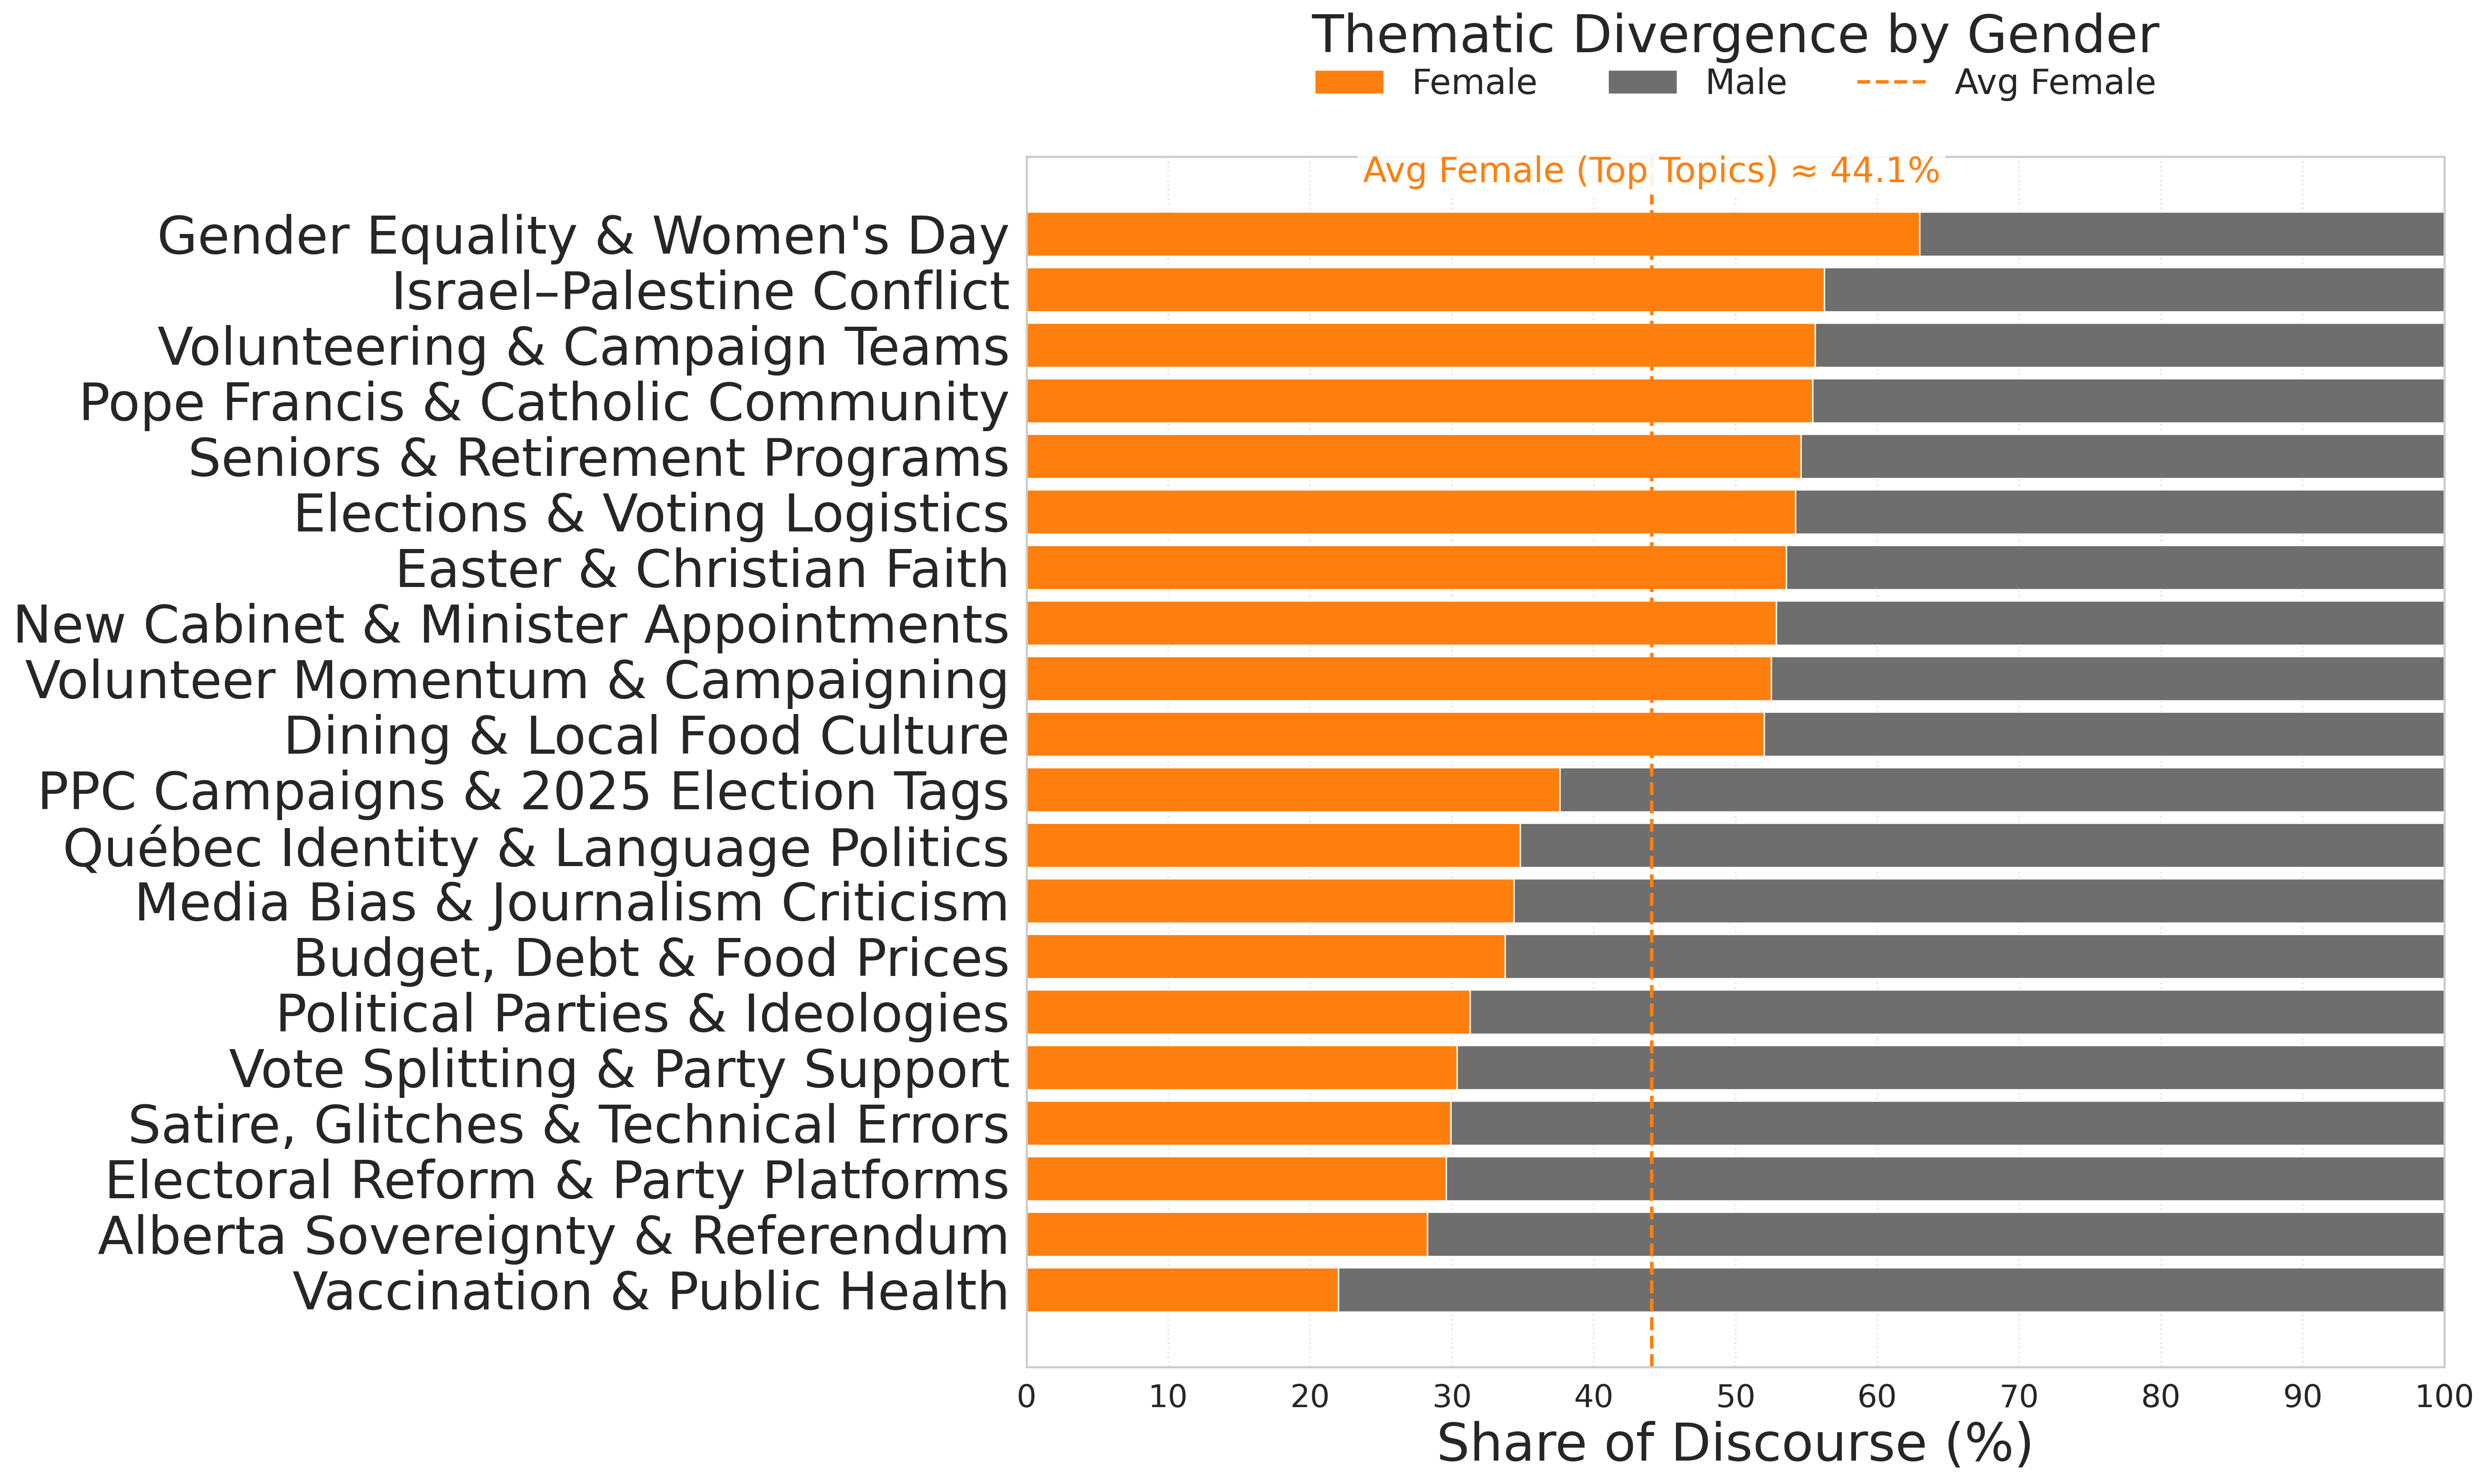

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

CAND_COL = "candidate_id"

df = pd.read_json("./data/canadian_election_2025_posts.jsonl", lines=True)
df["gender"] = df["gender"].str.strip().str.lower()

# 1) Top 50 topics (exclude outliers = -1)
top_topics = (
    df.loc[df["topic_id"] >= 0, "topic_id"]
      .value_counts()
      .head(50)
      .index
      .tolist()
)
top_topics_set = set(top_topics)
top_topics_set.discard(0)
top_topics_set.discard(1)

# 2) Keep only posts in top topics
df_top = df[df["topic_id"].isin(top_topics_set)].copy()
df_top["topic_label"] = df_top["topic_id"].apply(
    lambda t: custom_labels.get(int(t), f"Topic {int(t)}")
)

# 3) Minimum 500 posts per topic
topic_counts = df_top.groupby("topic_label").size()
valid_topics = topic_counts[topic_counts >= 500].index
df_top = df_top[df_top["topic_label"].isin(valid_topics)]

# 4) Per-candidate posting rate (paper methodology)
post_counts = df_top.groupby(["topic_label", "gender"]).size().unstack(fill_value=0)
unique_users = df_top.groupby(["topic_label", "gender"])[CAND_COL].nunique().unstack(fill_value=0)

for g in ["female", "male"]:
    if g not in post_counts.columns:
        post_counts[g] = 0
    if g not in unique_users.columns:
        unique_users[g] = 0

female_rate = post_counts["female"] / unique_users["female"].replace(0, np.nan)
male_rate   = post_counts["male"]   / unique_users["male"].replace(0, np.nan)

total_rate = female_rate + male_rate
df_pct = pd.DataFrame({
    "female": (female_rate / total_rate).fillna(0),
    "male":   (male_rate / total_rate).fillna(0),
})

# 5) Sort, pick bottom 10 + top 10
df_sorted_all = df_pct.sort_values("female", ascending=True)
female_avg_pct = 100 * df_sorted_all["female"].mean()

df_topics_sorted = pd.concat([
    df_sorted_all.head(10),
    df_sorted_all.tail(10)
]).sort_values("female", ascending=True)

print(f"Topics after 500-post filter: {len(df_sorted_all)}")
print(f"Avg female share (per-candidate normalized): {female_avg_pct:.1f}%")

# ---- Plot ----
y = np.arange(len(df_topics_sorted))
left = np.zeros(len(df_topics_sorted))

fig, ax = plt.subplots(figsize=(20, 12), dpi=300)

for gender in ["female", "male"]:
    label = "Female" if gender == "female" else "Male"
    ax.barh(
        y,
        df_topics_sorted[gender].values * 100,
        left=left * 100,
        color=GENDER_PALETTE.get(label, "gray"),
        label=label,
        edgecolor="white",
        linewidth=0.8
    )
    left += df_topics_sorted[gender].values

ax.axvline(
    female_avg_pct,
    color=GENDER_PALETTE.get("Female", "orange"),
    linestyle="--",
    linewidth=2.0
)

ax.text(
    female_avg_pct, y[-1] + 0.8,
    f"Avg Female (Top Topics) ≈ {female_avg_pct:.1f}%",
    ha="center", va="bottom", fontsize=20,
    color=GENDER_PALETTE.get("Female", "orange"),
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=3)
)

ax.set_yticks(y)
ax.set_yticklabels(df_topics_sorted.index, fontsize=30)
ax.set_xlim(0, 100)
ax.set_xlabel("Share of Discourse (%)", fontsize=30)
ax.set_title("Thematic Divergence by Gender", fontsize=30, pad=60)

ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.tick_params(axis="x", labelsize=18)
ax.grid(axis="x", linestyle=":", alpha=0.5)

line_proxy = Line2D(
    [0], [0],
    color=GENDER_PALETTE.get("Female", "orange"),
    linestyle="--", linewidth=2.0,
    label="Avg Female"
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles + [line_proxy],
    labels + ["Avg Female"],
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    fontsize=20,
    frameon=False
)

plt.tight_layout()
plt.savefig("icwsm_topic_gender_final.png", dpi=300)
plt.show()

In [34]:

# --- Overall female share: ALL topics vs Top 50 ---
# (per-candidate normalized, same methodology as Figure 5)

CAND_COL = "candidate_id"

df_all = pd.read_json("./data/canadian_election_2025_posts.jsonl", lines=True)
df_all["gender"] = df_all["gender"].str.strip().str.lower()

# ALL topics (exclude only outlier = -1 and noise 0, 1)
df_valid = df_all[df_all["topic_id"] >= 2].copy()

post_counts_all = df_valid.groupby(["topic_id", "gender"]).size().unstack(fill_value=0)
unique_users_all = df_valid.groupby(["topic_id", "gender"])[CAND_COL].nunique().unstack(fill_value=0)

for g in ["female", "male"]:
    if g not in post_counts_all.columns:
        post_counts_all[g] = 0
    if g not in unique_users_all.columns:
        unique_users_all[g] = 0

female_rate_all = post_counts_all["female"] / unique_users_all["female"].replace(0, np.nan)
male_rate_all   = post_counts_all["male"]   / unique_users_all["male"].replace(0, np.nan)

total_rate_all = female_rate_all + male_rate_all
df_pct_all = pd.DataFrame({
    "female": (female_rate_all / total_rate_all).fillna(0),
    "male":   (male_rate_all / total_rate_all).fillna(0),
})

overall_female_avg = 100 * df_pct_all["female"].mean()
print(f"Number of topics (all, excl. noise): {len(df_pct_all)}")
print(f"Overall avg female share (ALL topics, per-candidate normalized): {overall_female_avg:.1f}%")
print(f"Top-50 avg female share (from Figure 5 cell above):             {female_avg_pct:.1f}%")


Number of topics (all, excl. noise): 84
Overall avg female share (ALL topics, per-candidate normalized): 43.9%
Top-50 avg female share (from Figure 5 cell above):             44.1%


## Figure Gender Axis
Distributions of aggregate alignment scores on the
gender axis for male (gray) and female (orange) candidates.

In [23]:

with open("./data/embedding_state.json", "r", encoding="utf-8") as f:
    raw = json.load(f)

embedding_state = {
    int(k): {"sum": np.array(v["sum"]), "count": v["count"]}
    for k, v in raw.items()
}

user_properties = (
    df[['candidate_name', 'candidate_id', 'party', 'gender']]
    .drop_duplicates('candidate_id')
    .set_index('candidate_id')
    .to_dict(orient='index')
)


In [24]:

seed_ids = []
embeds   = []
genders  = []
party = []


for sid, st in embedding_state.items():
    if sid not in user_properties:  # guard
        continue
    # user embedding = mean of that user's post embeddings
    e = st["sum"] / max(st["count"], 1)
    if np.any(~np.isfinite(e)):
        continue  # skip NaN/inf users
    seed_ids.append(sid)
    embeds.append(e.astype(np.float32))

    g = (user_properties[sid].get("gender") or "").strip().title()
    genders.append(g)
    party.append(user_properties[sid].get("party"))


X_users = np.vstack(embeds)                  # shape: (n_users, d)
genders = np.array(genders)
df_users = pd.DataFrame({"candidate_id": seed_ids, "gender": genders,  "party": np.array(party)})

X_centered = X_users - X_users.mean(axis=0, keepdims=True)

fmask = (genders == "Female")
mmask = (genders == "Male")

assert fmask.sum() >= 5 and mmask.sum() >= 5, "Not enough users per gender to build axis."

muF = X_centered[fmask].mean(axis=0)
muM = X_centered[mmask].mean(axis=0)

u_gender = muF - muM
u_gender = u_gender / np.linalg.norm(u_gender)  # unit vector




        count      mean       std       min       25%       50%       75%  \
gender                                                                      
Female  311.0  0.143680  0.171235 -0.343789  0.035524  0.184820  0.273276   
Male    610.0  0.037971  0.185736 -0.411783 -0.106516  0.060788  0.181706   

             max  
gender            
Female  0.448817  
Male    0.406671  
AUC = 0.666 | KS D = 0.260, p = 9.86e-13
ACC@0 = 0.526 | Best threshold = 0.2552, ACC@best = 0.696
Permutation AUC mean=0.502, sd=0.020


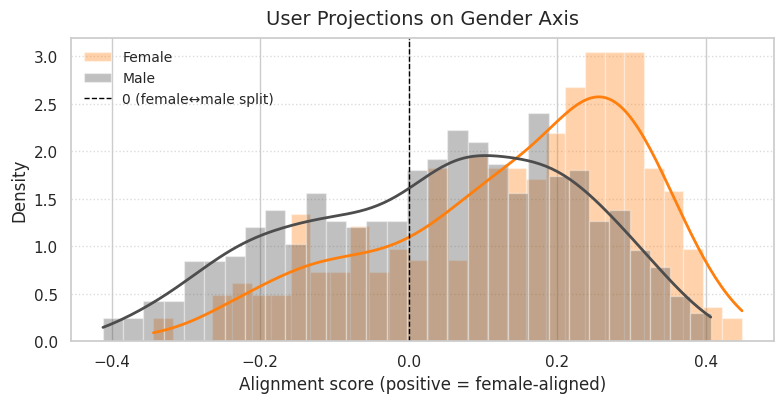

In [25]:

from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score


def project_on_axis(Z, axis):
    Z = Z / np.linalg.norm(Z, axis=1, keepdims=True)
    return Z @ axis

scores = project_on_axis(X_users, u_gender)   # >0 = female-aligned
y = (genders == 'Female').astype(int)         # Female=1, Male=0
df_scores = pd.DataFrame({'candidate_id': df_users['candidate_id'], 'gender': genders, 'score': scores})

print(df_scores.groupby('gender')['score'].describe())

auc = roc_auc_score(y, scores)
ks = ks_2samp(scores[genders=='Female'], scores[genders=='Male'])
print(f"AUC = {auc:.3f} | KS D = {ks.statistic:.3f}, p = {ks.pvalue:.2e}")


acc0 = np.mean(((scores > 0).astype(int) == y))

thr = np.quantile(scores, 0.5)
grid = np.linspace(scores.min(), scores.max(), 201)
accs = [(t, np.mean(((scores > t).astype(int) == y))) for t in grid]
t_star, acc_star = max(accs, key=lambda x: x[1])
print(f"ACC@0 = {acc0:.3f} | Best threshold = {t_star:.4f}, ACC@best = {acc_star:.3f}")


rng = np.random.default_rng(42)
null_aucs = []
for _ in range(200):
    y_perm = rng.permutation(y)
    null_aucs.append(roc_auc_score(y_perm, scores))
print(f"Permutation AUC mean={np.mean(null_aucs):.3f}, sd={np.std(null_aucs):.3f}")


colors = {'Female': '#FF7F0E', 'Male': '#4D4D4D'}
fig, ax = plt.subplots(figsize=(8,4.2))
for g in ['Female','Male']:
    s = df_scores.loc[df_scores['gender']==g, 'score']
    ax.hist(s, bins=30, density=True, alpha=0.35, color=colors[g], label=g)
    # kernel density (optional, safer for n>50)
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(s)
        xs = np.linspace(s.min(), s.max(), 200)
        ax.plot(xs, kde(xs), color=colors[g], linewidth=2)
    except Exception:
        pass

ax.axvline(0, color='black', linestyle='--', linewidth=1, label='0 (female↔male split)')
ax.set_title('User Projections on Gender Axis', fontsize=14, pad=10)
ax.set_xlabel('Alignment score (positive = female-aligned)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.grid(axis='y', linestyle=':', alpha=0.7)
ax.legend(frameon=False, fontsize=10)
plt.tight_layout(); plt.show()


## Figure Gendered linguistic by Party (Figure 7)

Figure 7: Gendered linguistic styles across Canadian political parties, showing alignment scores for male (gray) and
female (orange) candidates.

In [26]:
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

def build_gender_axis(X, genders):
    """Compute unit gender axis from user embeddings + labels."""
    fmask, mmask = genders == "Female", genders == "Male"
    if fmask.sum() < 2 or mmask.sum() < 2:
        return None
    muF, muM = X[fmask].mean(axis=0), X[mmask].mean(axis=0)
    u = muF - muM
    return u / np.linalg.norm(u)

def project_on_axis(Z, axis):
    Z = Z / np.linalg.norm(Z, axis=1, keepdims=True)
    return Z @ axis

def validate_axis(X, genders, axis):
    """Return summary stats for projections on axis."""
    scores = project_on_axis(X, axis)
    y = (genders == "Female").astype(int)
    # simple stats
    auc = roc_auc_score(y, scores) if len(np.unique(y)) == 2 else np.nan
    ks = ks_2samp(scores[genders=="Female"], scores[genders=="Male"])
    acc0 = np.mean(((scores > 0).astype(int) == y))
    return {
        "n_female": (genders=="Female").sum(),
        "n_male":   (genders=="Male").sum(),
        "mean_female": scores[genders=="Female"].mean(),
        "mean_male":   scores[genders=="Male"].mean(),
        "auc": auc,
        "ks_D": ks.statistic,
        "ks_p": ks.pvalue,
        "acc0": acc0
    }

def per_group_validation(X_users, genders, groups, level_name="platform"):
    """
    Run validation per group (Platform / Party).
    groups: array-like of same length as genders (user-level)
    """
    results = []
    for g in np.unique(groups):
        mask = (groups == g)
        Xg, gg = X_users[mask], genders[mask]
        axis = build_gender_axis(Xg, gg)
        if axis is None:
            continue
        stats = validate_axis(Xg, gg, axis)
        stats[level_name] = g
        results.append(stats)
    return pd.DataFrame(results)


In [27]:

party_results    = per_group_validation(X_users, genders, df_users['party'].values, "Party")
print(party_results.sort_values("auc", ascending=False))


   n_female  n_male  mean_female  mean_male       auc      ks_D          ks_p  \
1        54     173    -0.024329  -0.086481  0.768465  0.430850  2.087755e-07   
0        18      33     0.340231   0.222608  0.765993  0.560606  6.610279e-04   
2        37      45     0.030948  -0.118484  0.757357  0.477477  9.767203e-05   
5        23      98     0.292810   0.181429  0.756877  0.532831  2.040435e-05   
4        82      86     0.118904   0.011658  0.715258  0.425411  2.363994e-07   
3        97     168    -0.080871  -0.144359  0.691458  0.293508  3.483925e-05   

       acc0           Party  
1  0.801762    Conservative  
0  0.372549  Bloc Québécois  
2  0.682927           Green  
5  0.247934             PPC  
4  0.595238             NDP  
3  0.664151         Liberal  


In [28]:
scores = project_on_axis(X_users, u_gender)

# add scores back to df_users
df_scores = df_users.copy()
df_scores['score'] = scores


df_scores = df_scores[df_scores.party !="Others"]

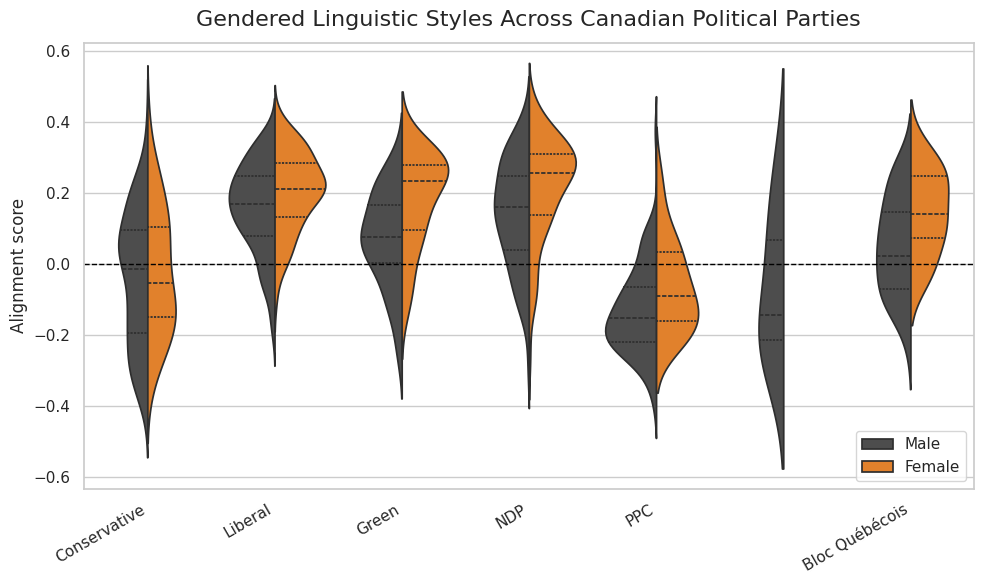

In [29]:

plt.figure(figsize=(10,6))
sns.violinplot(
    data=df_scores,
    x="party", y="score", hue="gender",
    split=True, inner="quartile",
    palette={"Female":"#FF7F0E","Male":"#4D4D4D"}
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Gendered Linguistic Styles Across Canadian Political Parties", fontsize=16, pad=12)
plt.ylabel("Alignment score")
plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.show()
